Bibliotecas e Configurações

In [ ]:
#Manipulação de dados
import pandas as pd
import numpy as np
import json
import os
import re
# Visualização de dados
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from matplotlib.ticker import StrMethodFormatter
# Machine Learning Preditiva
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics.pairwise import cosine_similarity
from datetime import timedelta



In [ ]:
#Configuração de Gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [ ]:
#Limpeza de erros
import warnings
warnings.filterwarnings('ignore')

Leitura dos Dados

In [ ]:
# Dicionário para mapear os arquivos
files = {
    "clientes_json": "clientes_crm.json",
    "custos_importacao_json": "custos_importacao.json",
    "produtos_csv": "produtos_raw.csv",
    "vendas_csv": "vendas_2023_2024.csv"
}

# Carregando os CSVs
df_produtos= pd.read_csv(files["produtos_csv"], sep=';')
df_vendas = pd.read_csv(files["vendas_csv"], sep=';')

# Carregando os JSONs
df_clientes = pd.read_json(files["clientes_json"])
df_custos = pd.read_json(files["custos_importacao_json"])

#EDA

 - Produtos

In [ ]:
print(f"--- Análise do Dataframe Produtos ---")
display(df_produtos.head())
print(df_produtos.info())
print(f"Valores nulos:\n{df_produtos.isnull().sum()}")

--- Análise do Dataframe Produtos ---


,"name,price,code,actual_category"
0,"Transponder AIS Maré Magnum,R$ 33122.52,1,ELET..."
1,"Transponder Furuno Marlin,R$ 13998.15,2,ELETRO..."
2,"Radar Furuno Pulse Leviathan,R$ 9024.19,3,E L ..."
3,"Rádio AIS Hydro Tidal Zen,R$ 3381.88,4,Eletrun..."
4,"Piloto Automático Furuno Storm,R$ 23669.01,5,E..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 1 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   name,price,code,actual_category  157 non-null    object
dtypes: object(1)
memory usage: 1.4+ KB
None
Valores nulos:
name,price,code,actual_category    0
dtype: int64


Erros Identificados

---


1 - Separador errado - subsituir por ,  
2 - price esta como "Object" - Mudar para float  

- Vendas

In [ ]:
print(f"--- Análise do Dataframe Vendas ---")
display(df_vendas.head())
print(df_vendas.info())
print(f"Valores nulos:\n{df_vendas.isnull().sum()}")

--- Análise do Dataframe Vendas ---


,"id,id_client,id_product,qtd,total,sale_date"
0,"0,42,105,11,3405.0,2023-09-10"
1,"1,3,136,9,16873.9,15-09-2024"
2,"2,25,139,7,9475.3,2024-08-13"
3,"4,20,23,5,55893.0,2023-02-03"
4,"5,8,57,4,451403.9,2024-02-12"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 1 columns):
 #   Column                                       Non-Null Count  Dtype 
---  ------                                       --------------  ----- 
 0   id,id_client,id_product,qtd,total,sale_date  9895 non-null   object
dtypes: object(1)
memory usage: 77.4+ KB
None
Valores nulos:
id,id_client,id_product,qtd,total,sale_date    0
dtype: int64


Erros Identificados

---


1 - Separador errado - subsituir por ,  
2 - sale date está com formatação mista - definir padrão

- Clientes

In [ ]:
print(f"--- Análise do Dataframe Clientes ---")
display(df_clientes.head())
print(df_clientes.info())
print(f"Valores nulos:\n{df_clientes.isnull().sum()}")

--- Análise do Dataframe Clientes ---


,full_name,location,code,email
0,Femininos Oliveira Antunes,"Aratu (Candeias) , BA",1,femininos.oliveira.antunes@icloud.com
1,Fernanda Azevedo Soares Nunes Vieira,"PE , Recife",2,nunes.fernanda.soares.azevedo.vieira@outlook.com
2,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro#gmail.com
3,Thiago Moreira,"AC , Rio Branco",4,thiago.moreira#gmail.com
4,Pedro Freitas,PA - Santarém Novo,5,pedro.freitas#icloud.com


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_name  49 non-null     object
 1   location   49 non-null     object
 2   code       49 non-null     int64 
 3   email      49 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.7+ KB
None
Valores nulos:
full_name    0
location     0
code         0
email        0
dtype: int64


Erros Identificados

---


1 - e-mails com # - Substituir por @

- Custos

In [ ]:
print(f"--- Análise do Dataframe Custos ---")
display(df_custos.head())
print(df_custos.info())
print(f"Valores nulos:\n{df_custos.isnull().sum()}")

--- Análise do Dataframe Custos ---


,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"[{'start_date': '10/08/2016', 'usd_price': 105..."
1,2,Transponder Furuno Marlin,eletrônicos,"[{'start_date': '23/11/2017', 'usd_price': 432..."
2,3,Radar Furuno Pulse Leviathan,eletrônicos,"[{'start_date': '12/04/2016', 'usd_price': 254..."
3,4,Rádio AIS Hydro Tidal Zen,eletrônicos,"[{'start_date': '04/03/2016', 'usd_price': 909..."
4,5,Piloto Automático Furuno Storm,eletrônicos,"[{'start_date': '10/02/2016', 'usd_price': 600..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     150 non-null    int64 
 1   product_name   150 non-null    object
 2   category       150 non-null    object
 3   historic_data  150 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.8+ KB
None
Valores nulos:
product_id       0
product_name     0
category         0
historic_data    0
dtype: int64


Erros Identificados

---


1 - historic_data como dicionario - Abrir o dicionario

#Tratamento de Dados

- Aplicando correções

In [ ]:
# Mudando separador
df_produtos = pd.read_csv(files["produtos_csv"], sep=',')
df_vendas = pd.read_csv(files["vendas_csv"], sep=',')

# Mudando tipo de variavél
df_produtos['price'] = df_produtos['price'].str.replace(r'R\$\s*', '', regex=True).astype(float)

# Padronizando Datas
df_vendas['sale_date'] = pd.to_datetime(df_vendas['sale_date'], dayfirst=True, format='mixed')
# Correção de e-mails
df_clientes['email'] = df_clientes['email'].str.replace('#', '@')


- Conferindo os arquivos

- Produtos

In [ ]:
print(f"--- Análise do Dataframe Produtos ---")
display(df_produtos.head())
print(df_produtos.info())
print(f"Valores nulos:\n{df_produtos.isnull().sum()}")

--- Análise do Dataframe Produtos ---


,name,price,code,actual_category
0,Transponder AIS Maré Magnum,"33,122.52",1,ELETRONICOS
1,Transponder Furuno Marlin,"13,998.15",2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,"9,024.19",3,E L E T R Ô N I C O S
3,Rádio AIS Hydro Tidal Zen,"3,381.88",4,Eletrunicos
4,Piloto Automático Furuno Storm,"23,669.01",5,Eletronicoz


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 157 entries, 0 to 156
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             157 non-null    object 
 1   price            157 non-null    float64
 2   code             157 non-null    int64  
 3   actual_category  157 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 5.0+ KB
None
Valores nulos:
name               0
price              0
code               0
actual_category    0
dtype: int64




> Erros encontrados


---
1 - actual_category sem padrão

In [ ]:
print("Variações na coluna 'actual_category':")
print(df_produtos['actual_category'].value_counts())

Variações na coluna 'actual_category':
actual_category
AncorageM                9
Propução                 8
Ancoraguem               8
eletrônicos              7
Eletronicoz              7
E L E T R Ô N I C O S    6
ELETRONICOS              6
P R O P U L S Ã O        6
propulsão                6
PROPULSAO                6
Eletrunicos              5
Ancorajm                 5
eLeTrÔnIcOs              5
Propulssão               5
Propulção                5
Prop                     5
Encoragem                5
aNcOrAgEm                5
A N C O R A G E M        5
Eletrônicos              4
propulsao                4
EletrônicoS              3
Propulçao                3
Ancorajem                3
eletronicos              3
Ancoragem                3
Ancorajen                2
Eletronicos              2
Propulsam                2
Eletroniscos             2
pRoPuLsÃo                2
ancoragem                2
AnCoRaGeM                2
ELEtRÔNICOS              1
PrOpUlSãO                1




> 3 tipos de produtos, mas muitos erros de gramatica



In [ ]:
def limpar_categorias(nome):
    nome = str(nome).upper().replace(" ", "") # Remove espaços e padroniza

    if 'ELET' in nome:
        return 'ELETRONICOS'
    elif 'PROP' in nome:
        return 'PROPULSAO'
    elif 'ANCOR' in nome or 'ENCOR' in nome:
        return 'ANCORAGEM'
    else:
        return 'OUTROS' # Caso apareça algo totalmente novo

# Aplicando a função
df_produtos['actual_category'] = df_produtos['actual_category'].apply(limpar_categorias)

# Validando o resultado
print(df_produtos['actual_category'].value_counts())

actual_category
PROPULSAO      53
ANCORAGEM      53
ELETRONICOS    51
Name: count, dtype: int64


In [ ]:
print(f"--- Análise do Dataframe Produtos ---")
display(df_produtos.head())


--- Análise do Dataframe Produtos ---


,name,price,code,actual_category
0,Transponder AIS Maré Magnum,"33,122.52",1,ELETRONICOS
1,Transponder Furuno Marlin,"13,998.15",2,ELETRONICOS
2,Radar Furuno Pulse Leviathan,"9,024.19",3,ELETRONICOS
3,Rádio AIS Hydro Tidal Zen,"3,381.88",4,ELETRONICOS
4,Piloto Automático Furuno Storm,"23,669.01",5,ELETRONICOS




> Erros corrigidos



- Vendas

In [ ]:
print(f"--- Análise do Dataframe Vendas ---")
display(df_vendas.head())
print(df_vendas.info())
print(f"Valores nulos:\n{df_vendas.isnull().sum()}")

--- Análise do Dataframe Vendas ---


,id,id_client,id_product,qtd,total,sale_date
0,0,42,105,11,"3,405.00",2023-09-10
1,1,3,136,9,"16,873.90",2024-09-15
2,2,25,139,7,"9,475.30",2024-08-13
3,4,20,23,5,"55,893.00",2023-02-03
4,5,8,57,4,"451,403.90",2024-02-12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9895 entries, 0 to 9894
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          9895 non-null   int64         
 1   id_client   9895 non-null   int64         
 2   id_product  9895 non-null   int64         
 3   qtd         9895 non-null   int64         
 4   total       9895 non-null   float64       
 5   sale_date   9895 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(4)
memory usage: 464.0 KB
None
Valores nulos:
id            0
id_client     0
id_product    0
qtd           0
total         0
sale_date     0
dtype: int64





> Erros Corrigidos





- Clientes

In [ ]:
print(f"--- Análise do Dataframe Clientes ---")
display(df_clientes.head())
print(df_clientes.info())
print(f"Valores nulos:\n{df_clientes.isnull().sum()}")

--- Análise do Dataframe Clientes ---


,full_name,location,code,email
0,Femininos Oliveira Antunes,"Aratu (Candeias) , BA",1,femininos.oliveira.antunes@icloud.com
1,Fernanda Azevedo Soares Nunes Vieira,"PE , Recife",2,nunes.fernanda.soares.azevedo.vieira@outlook.com
2,Daniel Farias Ribeiro Teixeira,"Rio Grande,RS",3,farias.teixeira.daniel.ribeiro@gmail.com
3,Thiago Moreira,"AC , Rio Branco",4,thiago.moreira@gmail.com
4,Pedro Freitas,PA - Santarém Novo,5,pedro.freitas@icloud.com


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   full_name  49 non-null     object
 1   location   49 non-null     object
 2   code       49 non-null     int64 
 3   email      49 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.7+ KB
None
Valores nulos:
full_name    0
location     0
code         0
email        0
dtype: int64



 - Erros
---

> Localização sem formatação


> Prefixo na frente de alguns nomes





In [ ]:
print("Variações na coluna 'full_name':")
print(df_clientes['full_name'].value_counts())

Variações na coluna 'full_name':
full_name
Femininos Oliveira Antunes                     1
Fernanda Azevedo Soares Nunes Vieira           1
Daniel Farias Ribeiro Teixeira                 1
Thiago Moreira                                 1
Pedro Freitas                                  1
Antônia Coelho Pinheiro Peixoto Cavalcanti     1
Bianca Barros Rocha Torres Siqueira            1
Luiz Alves Pimentel                            1
Lucas Guedes Cunha Lopes                       1
Débora Paiva                                   1
Victor Torres Monteiro                         1
Rafael Pereira Barros                          1
Carlos Guimarães Martins                       1
Gabriela Silva Vieira Amaral                   1
Carla Lopes Alves Pacheco Rocha                1
Renata Pacheco Cardoso                         1
Luís Paiva Costa Cardoso Coelho                1
Adriana Guedes Borges Alves Rocha              1
Renata Lima Gomes Coelho Mendonça              1
Bruno Silva               

In [ ]:
# Lista de prefixos
prefixos = ['Femininos ', 'Masculinos ', 'Feminino ', 'Masculino ']

# Criando um padrão de busca esses termos no inicio
padrao_prefixos = r'^(' + '|'.join(prefixos) + r')'

df_clientes['full_name'] = df_clientes['full_name'].str.replace(padrao_prefixos, '', regex=True, case=False).str.strip()

In [ ]:
# Para formatar localização ela sera separada em duas colunas

# Extraindo a sigla do estado
def extrair_uf(txt):
    match = re.search(r'\b([A-Z]{2})\b', str(txt).upper())
    return match.group(1) if match else None

#Criando coluna state
df_clientes['state'] = df_clientes['location'].apply(extrair_uf)

# Removemos a sigla do estado e os caracteres especiais da string original
def limpar_cidade(txt):
    # Remove a Estado
    txt = re.sub(r'\b[A-Z]{2}\b', '', str(txt))
    # Remove caracteres especias
    txt = re.sub(r'[,()\-]', ' ', txt)
    return " ".join(txt.split()).strip()

# Criando coluna city
df_clientes['city'] = df_clientes['location'].apply(limpar_cidade)

# Deletando a colunaa location
df_clientes.drop(columns=['location'], inplace=True)

In [ ]:
print(f"--- Análise do Dataframe Clientes ---")
display(df_clientes.head())

--- Análise do Dataframe Clientes ---


,full_name,code,email,state,city
0,Oliveira Antunes,1,femininos.oliveira.antunes@icloud.com,BA,Aratu Candeias
1,Fernanda Azevedo Soares Nunes Vieira,2,nunes.fernanda.soares.azevedo.vieira@outlook.com,PE,Recife
2,Daniel Farias Ribeiro Teixeira,3,farias.teixeira.daniel.ribeiro@gmail.com,RS,Rio Grande
3,Thiago Moreira,4,thiago.moreira@gmail.com,AC,Rio Branco
4,Pedro Freitas,5,pedro.freitas@icloud.com,PA,Santarém Novo


- Erros Corrigidos

In [ ]:
print(f"--- Análise do Dataframe Custos ---")
display(df_custos.head())
print(df_custos.info())
print(f"Valores nulos:\n{df_custos.isnull().sum()}")

--- Análise do Dataframe Custos ---


,product_id,product_name,category,historic_data
0,1,Transponder AIS Maré Magnum,eletrônicos,"[{'start_date': '10/08/2016', 'usd_price': 105..."
1,2,Transponder Furuno Marlin,eletrônicos,"[{'start_date': '23/11/2017', 'usd_price': 432..."
2,3,Radar Furuno Pulse Leviathan,eletrônicos,"[{'start_date': '12/04/2016', 'usd_price': 254..."
3,4,Rádio AIS Hydro Tidal Zen,eletrônicos,"[{'start_date': '04/03/2016', 'usd_price': 909..."
4,5,Piloto Automático Furuno Storm,eletrônicos,"[{'start_date': '10/02/2016', 'usd_price': 600..."


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     150 non-null    int64 
 1   product_name   150 non-null    object
 2   category       150 non-null    object
 3   historic_data  150 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.8+ KB
None
Valores nulos:
product_id       0
product_name     0
category         0
historic_data    0
dtype: int64



- Erros
> historic_data continua como dicionario





> Para separar o que da dentro da coluna vou transformar cada dicionario em uma linha



In [ ]:
# Expandir o arquivos
df_expandido = df_custos.explode('historic_data')
#Transformar os dicionarios em colunas
df_expandido = df_expandido.reset_index(drop=True)
colunas_historico = pd.json_normalize(df_expandido['historic_data'])
# Combinar tudo e remover historic_data
df_custos_corrigido = pd.concat([df_expandido.drop(columns=['historic_data']), colunas_historico], axis=1)

# Converter as colunas para o pradão apropriado
df_custos_corrigido['start_date'] = pd.to_datetime(df_custos_corrigido['start_date'], dayfirst=True)
df_custos_corrigido['usd_price'] = pd.to_numeric(df_custos_corrigido['usd_price'])

# Calcular o ultimo_custo_usd para df_custos_corrigido
# Primeiro, ordenar por product_id e start_date
df_custos_corrigido_sorted = df_custos_corrigido.sort_values(by=['product_id', 'start_date'])
# Em seguida, agrupar por product_id e pegar o último usd_price
ultimo_custo_por_produto = df_custos_corrigido_sorted.groupby('product_id')['usd_price'].last().reset_index()
ultimo_custo_por_produto = ultimo_custo_por_produto.rename(columns={'usd_price': 'ultimo_custo_usd'})

# Mergear o ultimo_custo_usd de volta ao df_custos_corrigido (para ter a coluna disponível para o merge final)
df_custos_corrigido = pd.merge(df_custos_corrigido, ultimo_custo_por_produto, on='product_id', how='left')

In [ ]:
print(f"--- Análise do Dataframe Custos ---")
display(df_custos_corrigido.head())

--- Análise do Dataframe Custos ---


,product_id,product_name,category,start_date,usd_price,ultimo_custo_usd
0,1,Transponder AIS Maré Magnum,eletrônicos,2016-08-10,"10,583.63","5,579.75"
1,1,Transponder AIS Maré Magnum,eletrônicos,2018-06-15,"8,778.36","5,579.75"
2,1,Transponder AIS Maré Magnum,eletrônicos,2018-09-25,"8,023.87","5,579.75"
3,1,Transponder AIS Maré Magnum,eletrônicos,2019-03-19,"8,772.78","5,579.75"
4,1,Transponder AIS Maré Magnum,eletrônicos,2020-01-17,"7,918.18","5,579.75"




> Erros corrigidos



- Juntando tudo em um daframe unico

In [ ]:
# Vendas + Clientes ( id_client <-> code)
df_final = pd.merge(df_vendas, df_clientes, left_on='id_client', right_on='code', how='left')
# df_final + Produtos ( id_product <-> code)
df_final = pd.merge(df_final, df_produtos, left_on='id_product', right_on='code', how='left')
# df_final + Custos (id_product <-> product_id)
df_final = pd.merge(df_final, df_custos_corrigido[['product_id', 'ultimo_custo_usd']],
                    left_on='id_product', right_on='product_id', how='left')

# Removemos as colunas duplicadas
df_final.drop(columns=['code_x', 'code_y', 'product_id'], inplace=True, errors='ignore')


In [ ]:
print(f"--- Análise do Dataframe Final ---")
display(df_final.head())
print(df_final.info())
print(df_final.isnull().sum())

--- Análise do Dataframe Final ---


,id,id_client,id_product,qtd,total,sale_date,full_name,email,state,city,name,price,actual_category,ultimo_custo_usd
0,0,42,105,11,"3,405.00",2023-09-10,Márcia Figueiredo,márcia.figueiredo@protonmail.com,DO,Vila do Conde Barcarena,Cabo de Nylon Danforth Prime,309.54,ANCORAGEM,53.37
1,0,42,105,11,"3,405.00",2023-09-10,Márcia Figueiredo,márcia.figueiredo@protonmail.com,DO,Vila do Conde Barcarena,Cabo de Nylon Danforth Prime,309.54,ANCORAGEM,53.37
2,0,42,105,11,"3,405.00",2023-09-10,Márcia Figueiredo,márcia.figueiredo@protonmail.com,DO,Vila do Conde Barcarena,Cabo de Nylon Danforth Prime,309.54,ANCORAGEM,53.37
3,0,42,105,11,"3,405.00",2023-09-10,Márcia Figueiredo,márcia.figueiredo@protonmail.com,DO,Vila do Conde Barcarena,Cabo de Nylon Danforth Prime,309.54,ANCORAGEM,53.37
4,0,42,105,11,"3,405.00",2023-09-10,Márcia Figueiredo,márcia.figueiredo@protonmail.com,DO,Vila do Conde Barcarena,Cabo de Nylon Danforth Prime,309.54,ANCORAGEM,53.37


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86301 entries, 0 to 86300
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                86301 non-null  int64         
 1   id_client         86301 non-null  int64         
 2   id_product        86301 non-null  int64         
 3   qtd               86301 non-null  int64         
 4   total             86301 non-null  float64       
 5   sale_date         86301 non-null  datetime64[ns]
 6   full_name         86301 non-null  object        
 7   email             86301 non-null  object        
 8   state             86301 non-null  object        
 9   city              86301 non-null  object        
 10  name              86301 non-null  object        
 11  price             86301 non-null  float64       
 12  actual_category   86301 non-null  object        
 13  ultimo_custo_usd  86301 non-null  float64       
dtypes: datetime64[ns](1), 

Dataframe Finalizado

# Análise de Vendas

- Dados Publicos

In [ ]:
def get_cambio_bacen(data_inicio, data_fim):
    # Código 10813 é o Dólar Americano (venda) no sistema do BACEN
    url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.10813/dados?formato=json&dataInicial={data_inicio}&dataFinal={data_fim}'
    df = pd.read_json(url)
    df['data'] = pd.to_datetime(df['data'], dayfirst=True)
    df['valor'] = df['valor'].astype(float)
    return df.rename(columns={'data': 'data_cotacao', 'valor': 'cotacao_venda'})

# Gerando a tabela para o intervalo
df_cambio = get_cambio_bacen('01/01/2023', '31/12/2024')

# Extraindo a média do período para manter a variável taxa_usd
# Usamos a média para que o cálculo reflita o intervalo todo, mantendo o nome da variável
taxa_usd = df_cambio['cotacao_venda'].mean()

print(f"Taxa de Câmbio média calculada (BACEN): {taxa_usd:.2f}")

Taxa de Câmbio média calculada (BACEN): 5.19


- Metricas de Lucro

In [ ]:

#  Custo Total da Venda em Reais
df_final['custo_total_brl'] = (df_final['ultimo_custo_usd'] * taxa_usd) * df_final['qtd']

# Lucro Bruto
df_final['lucro_bruto'] = df_final['total'] - df_final['custo_total_brl']

# Margem de Lucro (%)
df_final['margem_percentual'] = (df_final['lucro_bruto'] / df_final['total']) * 100

- Vendas por Categoria

Análise de Performance por Categoria:


,qtd_vendas,total,lucro_bruto
actual_category,,,
PROPULSAO,27174,"18,084,831,458.60","416,656,662.82"
ELETRONICOS,29660,"4,008,127,371.05","104,949,036.04"
ANCORAGEM,29467,"625,809,683.00","17,838,597.95"


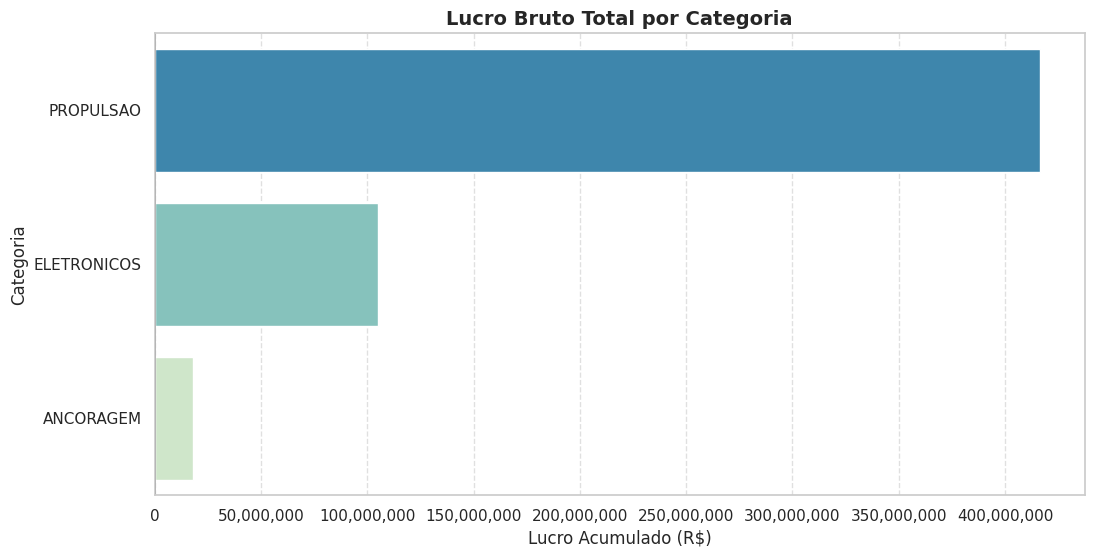

In [ ]:
analise_categoria = df_final.groupby('actual_category').agg({
    'id': 'count',           # Volume de vendas
    'total': 'sum',          # Faturamento total
    'lucro_bruto': 'sum'     # Lucro real
}).rename(columns={'id': 'qtd_vendas'}).sort_values(by='lucro_bruto', ascending=False)

print("Análise de Performance por Categoria:")
display(analise_categoria)

# Gráfico
plot_categoria = analise_categoria.reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_categoria, x='lucro_bruto', y='actual_category', palette="GnBu_r")
plt.title('Lucro Bruto Total por Categoria', fontsize=14, fontweight='bold')
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Lucro Acumulado (R$)', fontsize=12)
plt.ylabel('Categoria', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.axvline(0, color='black', linewidth=1.2)
plt.show()

- Vendas por dia da semana

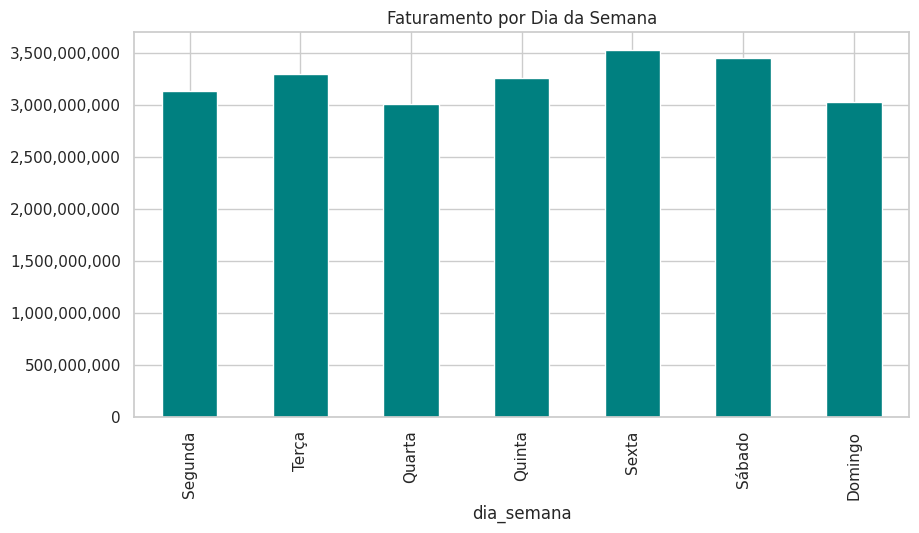

In [ ]:
# Traduzindo para portugues
dias_semana = {
    'Monday': 'Segunda', 'Tuesday': 'Terça', 'Wednesday': 'Quarta',
    'Thursday': 'Quinta', 'Friday': 'Sexta', 'Saturday': 'Sábado', 'Sunday': 'Domingo'
}
df_final['dia_semana'] = df_final['sale_date'].dt.day_name().map(dias_semana)

# Agrupando
vendas_por_dia = df_final.groupby('dia_semana')['total'].sum().reindex(
    ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
)

#Gráfico
def currency_formatter(x, pos):
    return f'{x:,.0f}'
vendas_por_dia.plot(kind='bar', figsize=(10,5), color='teal', title='Faturamento por Dia da Semana')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(currency_formatter))
plt.show()

- Prejuizos

Alerta: Temos 77 produtos operando no prejuízo!


,name,actual_category,total,custo_total_brl,lucro_bruto
14,Cabo de Nylon Bruce Flux Hydro,ANCORAGEM,"16,873.90","18,262.24","-1,388.34"
15,Cabo de Nylon Bruce Flux Hydro,ANCORAGEM,"16,873.90","18,262.24","-1,388.34"
16,Cabo de Nylon Bruce Flux Hydro,ANCORAGEM,"16,873.90","18,262.24","-1,388.34"
17,Cabo de Nylon Bruce Flux Hydro,ANCORAGEM,"16,873.90","18,262.24","-1,388.34"
18,Cabo de Nylon Bruce Flux Hydro,ANCORAGEM,"16,873.90","18,262.24","-1,388.34"


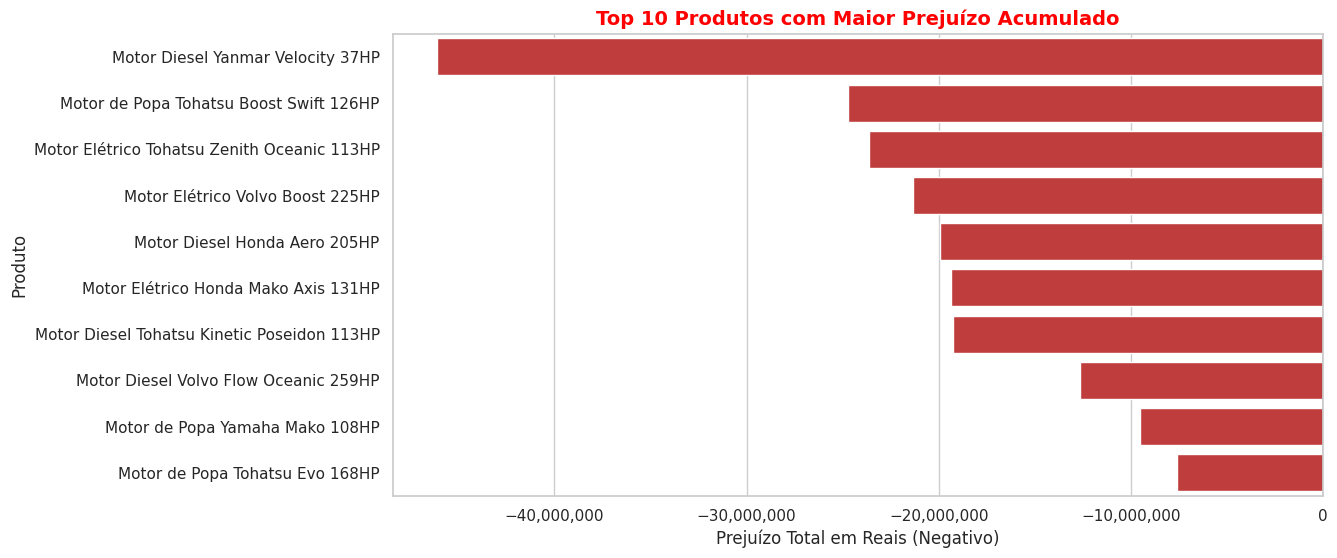

In [ ]:
# Produtos onde o lucro é negativo indica prejuizo
produtos_prejuizo = df_final[df_final['lucro_bruto'] < 0]

print(f"Alerta: Temos {produtos_prejuizo['name'].nunique()} produtos operando no prejuízo!")
display(produtos_prejuizo[['name', 'actual_category', 'total', 'custo_total_brl', 'lucro_bruto']].head())

prejuizos_acumulados = df_final[df_final['lucro_bruto'] < 0].groupby('name')['lucro_bruto'].sum().sort_values().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=prejuizos_acumulados.values, y=prejuizos_acumulados.index, color='#d62728')
plt.title('Top 10 Produtos com Maior Prejuízo Acumulado', fontsize=14, fontweight='bold', color='red')
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Prejuízo Total em Reais (Negativo)', fontsize=12)
plt.ylabel('Produto', fontsize=12)
plt.axvline(0, color='black', linewidth=1)
plt.show()

- Top 10 Produtos mais vendidos

--- Top 10 Produtos (Faturamento) ---


,qtd,total,lucro_bruto
name,,,
Motor Diesel Honda Aero 205HP,8092,"1,169,550,751.60","-9,974,004.96"
Motor Diesel Yanmar Velocity 37HP,10752,"1,071,000,338.40","-46,103,033.28"
Motor de Popa Torqeedo Core Hydra Flux 162HP,6958,"973,759,567.20","34,438,732.73"
Motor Elétrico Torqeedo Pulse 300HP,7051,"897,237,733.15","51,135,064.67"
Motor Elétrico Torqeedo Barracuda Magnum Helix 101HP,5918,"706,146,403.60","36,718,423.33"
Motor Elétrico Honda Flux Ultra 273HP,6432,"673,141,235.40","80,666,283.40"
Motor Elétrico Yamaha Nautic Kraken 133HP,6990,"601,831,023.75","12,155,065.19"
Motor de Popa Honda Velocity Drift 258HP,5555,"587,603,852.00","31,793,819.07"
Motor Diesel Tohatsu Evo Zenith 16HP,8745,"548,318,853.75","13,682,611.27"


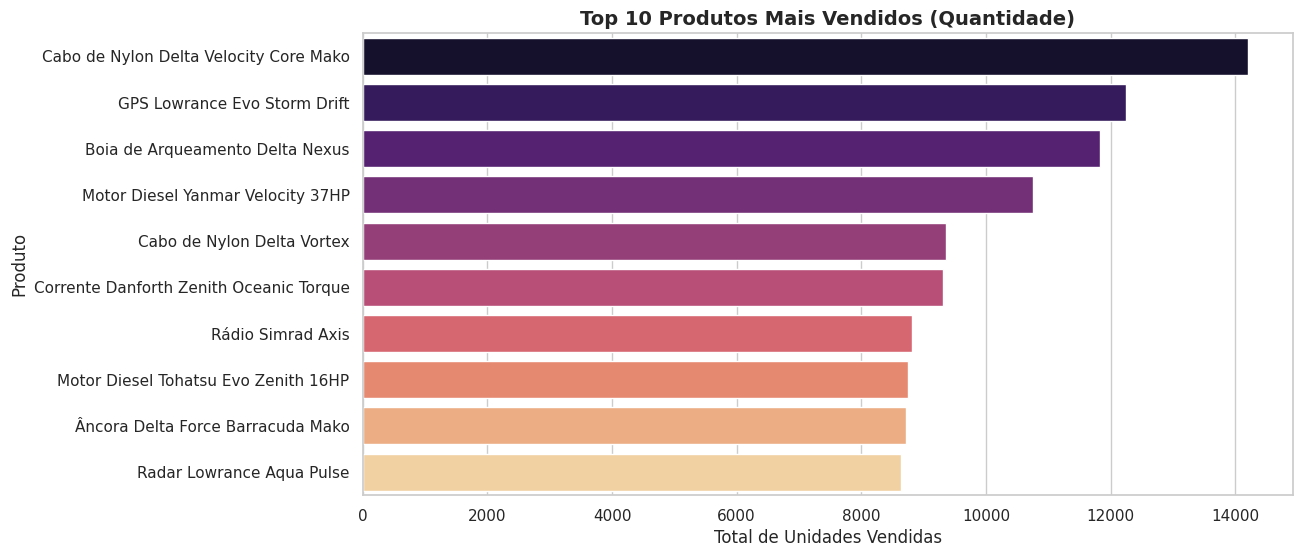

In [ ]:
# Produtos mais vendidos
top_10_produtos = df_final.groupby('name').agg({
    'qtd': 'sum',
    'total': 'sum',
    'lucro_bruto': 'sum'
}).sort_values(by='total', ascending=False).head(10)

print("--- Top 10 Produtos (Faturamento) ---")
display(top_10_produtos)


# Gráfico
top_prods_qtd = df_final.groupby('name')['qtd'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_prods_qtd.values, y=top_prods_qtd.index, palette="magma")
plt.title('Top 10 Produtos Mais Vendidos (Quantidade)', fontsize=14, fontweight='bold')
plt.xlabel('Total de Unidades Vendidas', fontsize=12)
plt.ylabel('Produto', fontsize=12)
plt.show()

- Vendas por Estado

--- Top Estados por Lucro ---


,total,lucro_bruto,qtd_pedidos
state,,,
PA,"3,266,741,370.45","78,024,975.59",12298
BA,"2,200,362,737.10","56,591,101.70",8401
DO,"1,609,936,698.65","43,477,971.96",5767
PB,"1,470,089,046.55","42,453,339.18",5429
SE,"1,504,384,995.75","41,205,201.11",5193
AM,"1,397,032,170.00","36,492,005.63",5389
PE,"1,456,000,233.15","31,257,253.13",5387
CE,"1,194,887,400.65","26,225,313.43",5057
TO,"978,166,720.35","25,378,034.48",3538


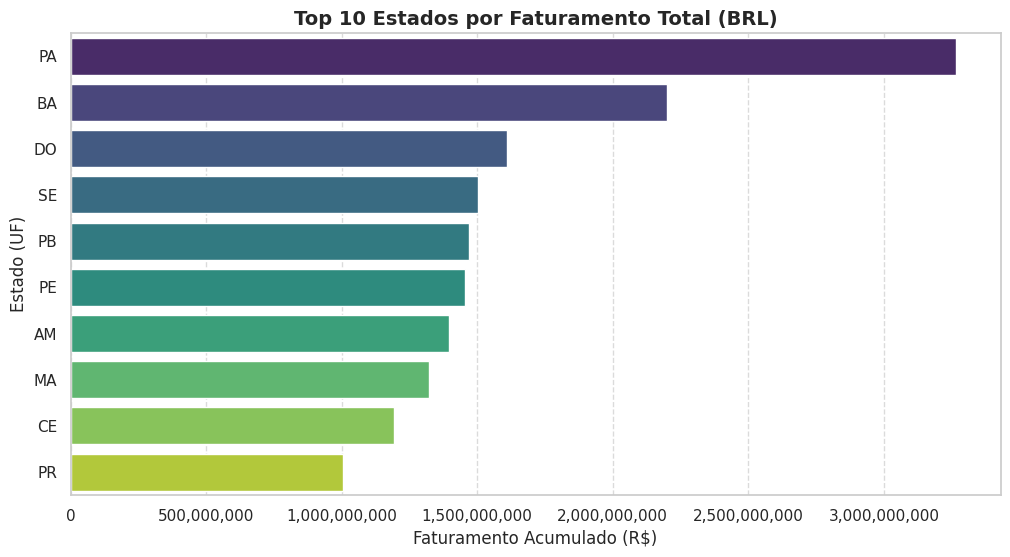

In [ ]:
analise_regional = df_final.groupby('state').agg({
    'total': 'sum',
    'lucro_bruto': 'sum',
    'id': 'count'
}).rename(columns={'id': 'qtd_pedidos'}).sort_values(by='lucro_bruto', ascending=False)

print("--- Top Estados por Lucro ---")
display(analise_regional.head(10))

# Gráfico
# 10 estados com maior faturamento
top_estados = df_final.groupby('state')['total'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_estados.values, y=top_estados.index, palette="viridis")
plt.title('Top 10 Estados por Faturamento Total (BRL)', fontsize=14, fontweight='bold')
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Faturamento Acumulado (R$)', fontsize=12)
plt.ylabel('Estado (UF)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

- Vendas ao longo do tempo, indicativo de sazonalidade

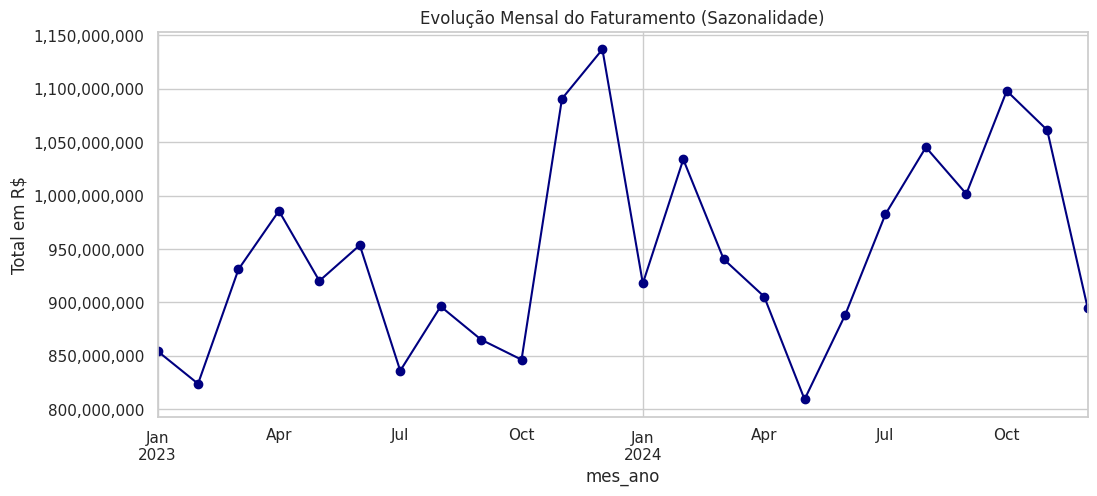

In [ ]:
# Coluna de mês/ano para o gráfico
df_final['mes_ano'] = df_final['sale_date'].dt.to_period('M')

sazonalidade = df_final.groupby('mes_ano')['total'].sum()

plt.figure(figsize=(12,5))
sazonalidade.plot(kind='line', marker='o', color='navy')
plt.title('Evolução Mensal do Faturamento (Sazonalidade)')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.ylabel('Total em R$')
plt.grid(True)
plt.show()

# Análise de Clientes

- Top 10 Clientes Por Lucro Bruto

--- Top 10 Clientes mais Lucrativos ---


,,total,lucro_bruto,qtd_compras
full_name,state,,,
Lucas Guedes Cunha Lopes,PB,"638,636,225.00","22,377,922.90",1988
Carla Lopes Alves Pacheco Rocha,DO,"565,265,619.30","18,418,338.48",2091
Antunes Lopes Ribeiro Amaral,ES,"565,647,914.60","18,226,286.81",1937
Fernanda Azevedo Soares Nunes Vieira,PE,"557,147,851.05","17,313,477.88",1855
Oliveira Antunes,BA,"457,106,687.80","17,052,696.61",1668
Mateus Antunes,TO,"511,895,865.60","16,526,692.13",1809
Daniela Borges Vieira Farias Mendonça,SE,"507,248,568.10","15,596,411.97",1624
Gabriela Silva Vieira Amaral,AM,"498,234,263.55","15,007,802.01",1859
Francisca Ribeiro Pinheiro,PA,"584,379,575.65","14,822,340.97",1864


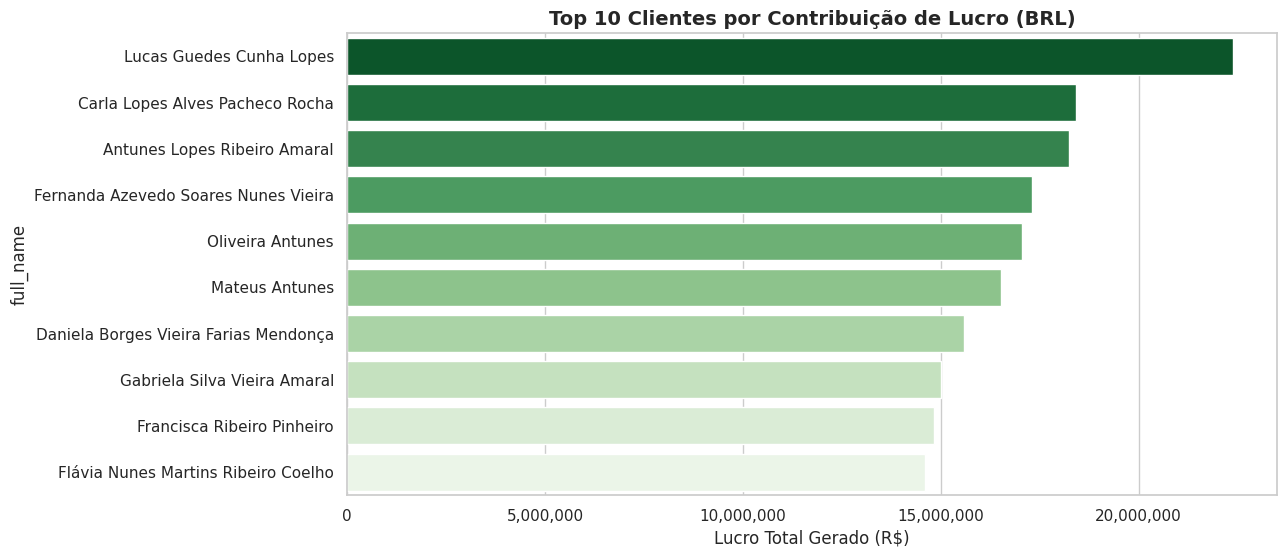

In [ ]:
top_10_lucro_clientes = df_final.groupby(['full_name', 'state']).agg({
    'total': 'sum',
    'lucro_bruto': 'sum',
    'id': 'count'
}).rename(columns={'id': 'qtd_compras'}).sort_values(by='lucro_bruto', ascending=False).head(10)

print("--- Top 10 Clientes mais Lucrativos ---")
display(top_10_lucro_clientes)

# Gráfico de Barras para o Lucro dos VIPS
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_lucro_clientes['lucro_bruto'], y=top_10_lucro_clientes.index.get_level_values(0), palette="Greens_r")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title('Top 10 Clientes por Contribuição de Lucro (BRL)', fontsize=14, fontweight='bold')
plt.xlabel('Lucro Total Gerado (R$)')
plt.show()

- Top Frequencia de Compra


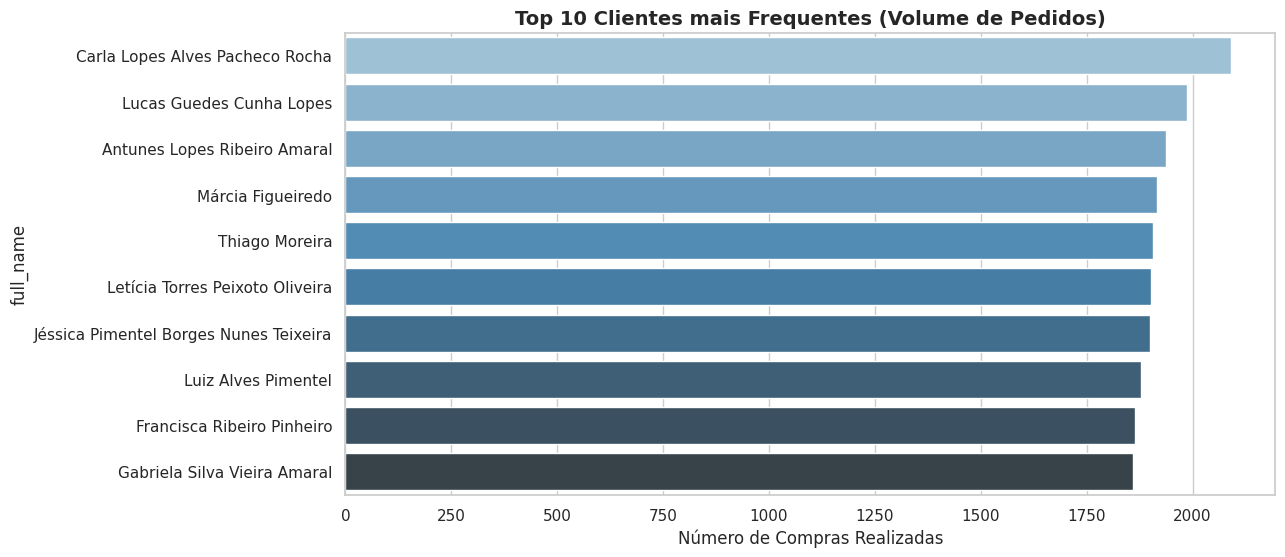

In [ ]:
top_frequencia = df_final.groupby('full_name')['id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_frequencia.values, y=top_frequencia.index, palette="Blues_d")
plt.title('Top 10 Clientes mais Frequentes (Volume de Pedidos)', fontsize=14, fontweight='bold')
plt.xlabel('Número de Compras Realizadas')
plt.show()

- Top 10 clientes por Gasto por Pedido

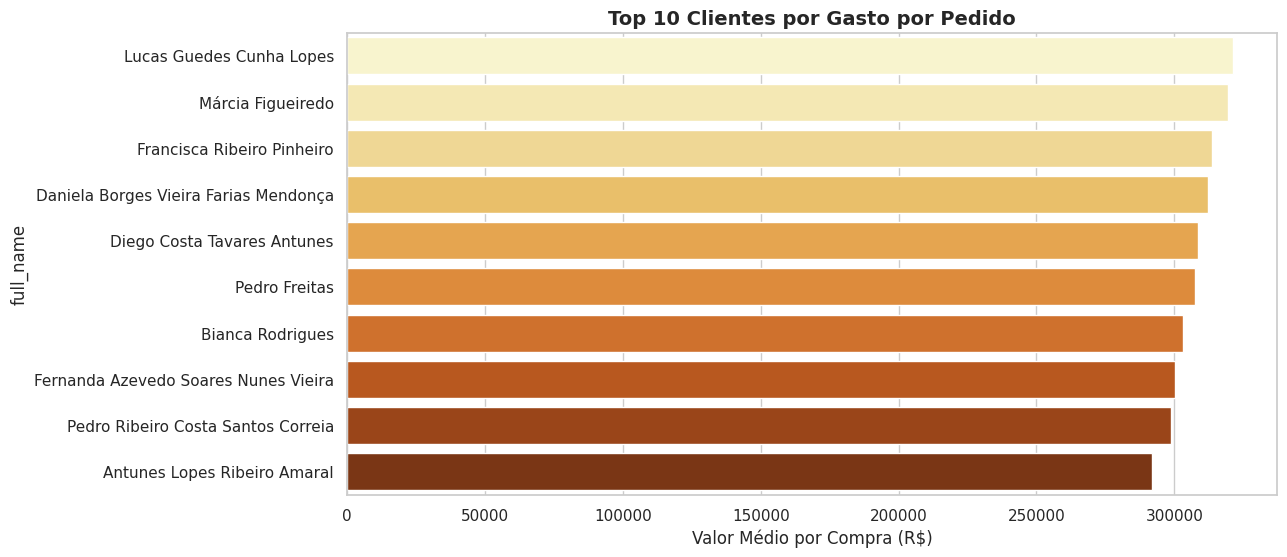

In [ ]:
medio_cliente = df_final.groupby('full_name').agg({
    'total': 'sum',
    'id': 'count'
})
medio_cliente['ticket_medio'] = medio_cliente['total'] / medio_cliente['id']

top_ticket = medio_cliente.sort_values(by='ticket_medio', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_ticket['ticket_medio'], y=top_ticket.index, palette="YlOrBr")
plt.title('Top 10 Clientes por Gasto por Pedido', fontsize=14, fontweight='bold')
plt.xlabel('Valor Médio por Compra (R$)')
plt.show()

- Clientes por Estado

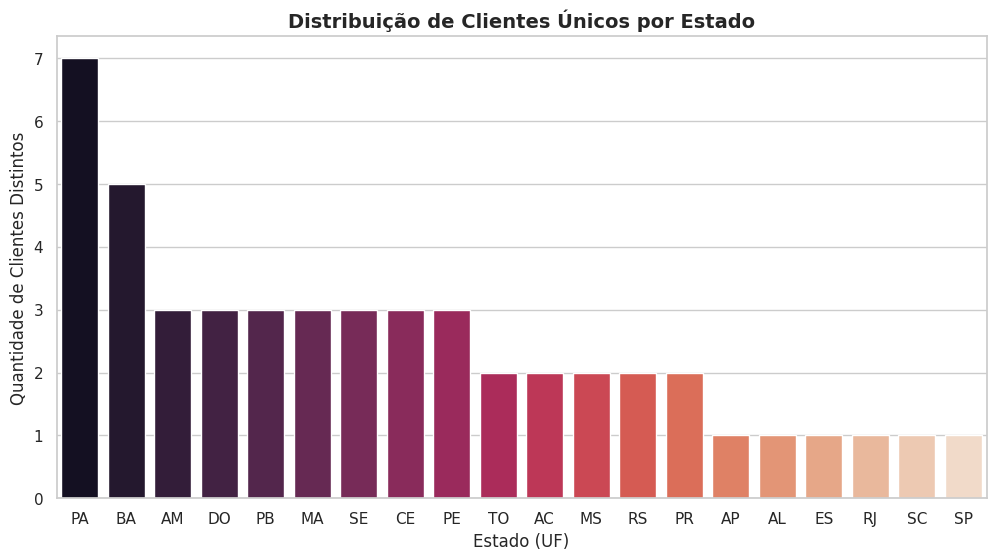

In [ ]:
clientes_por_estado = df_final.groupby('state')['id_client'].nunique().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=clientes_por_estado.index, y=clientes_por_estado.values, palette="rocket")
plt.title('Distribuição de Clientes Únicos por Estado', fontsize=14, fontweight='bold')
plt.ylabel('Quantidade de Clientes Distintos')
plt.xlabel('Estado (UF)')
plt.show()

- Clientes que mais geraram prejuizo

--- Clientes que Geraram Maior Prejuízo (BRL) ---


,,lucro_bruto,total,qtd_pedidos
full_name,state,,,
Luís Paiva Costa Cardoso Coelho,MS,"4,117,690.57","439,765,045.60",1827
Letícia Torres Peixoto Oliveira,PE,"4,428,227.89","516,429,709.90",1902
Victor Vieira Nunes Cunha,CE,"5,261,326.37","295,756,115.10",1484
Daniela Teixeira Antunes Coelho Batista,BA,"5,755,361.56","478,965,726.45",1647
Jéssica Figueiredo Leite Martins,MA,"5,882,480.95","399,246,847.05",1547
Jéssica Farias Cunha,MA,"5,929,818.17","452,239,069.95",1816
Ana Silva Costa Farias Coelho,AP,"6,603,608.11","472,211,953.75",1665
Lucas Pacheco,MS,"6,829,293.87","281,817,022.05",1528
Diego Costa Guedes Cunha,RS,"7,113,987.08","387,329,947.85",1836


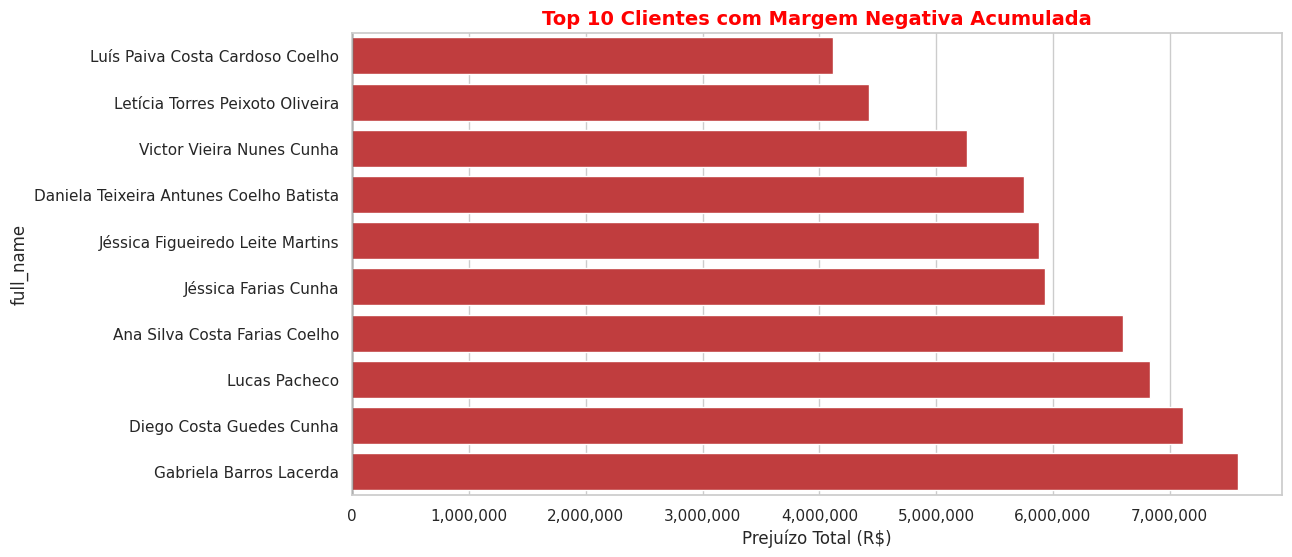

In [ ]:
# Filtrando apenas quem gerou lucro total negativo
piores_clientes_lucro = df_final.groupby(['full_name', 'state']).agg({
    'lucro_bruto': 'sum',
    'total': 'sum',
    'id': 'count'
}).rename(columns={'id': 'qtd_pedidos'}).sort_values(by='lucro_bruto', ascending=True).head(10)

print("--- Clientes que Geraram Maior Prejuízo (BRL) ---")
display(piores_clientes_lucro)

# Gráfico de Alerta
plt.figure(figsize=(12, 6))
sns.barplot(x=piores_clientes_lucro['lucro_bruto'], y=piores_clientes_lucro.index.get_level_values(0), color='#d62728')
plt.title('Top 10 Clientes com Margem Negativa Acumulada', fontsize=14, fontweight='bold', color='red')
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Prejuízo Total (R$)')
plt.axvline(0, color='black', linewidth=1)
plt.show()

- Clientes com menor Gasto por Produto

--- Clientes com Menor Gasto por Produto ---


,total,id,ticket_medio
full_name,,,
Lucas Pacheco,"281,817,022.05",1528,"184,435.22"
Victor Vieira Nunes Cunha,"295,756,115.10",1484,"199,296.57"
Flávia Nunes Martins Ribeiro Coelho,"369,247,742.60",1782,"207,209.73"
Diego Costa Guedes Cunha,"387,329,947.85",1836,"210,964.02"
Bruno Silva,"347,956,370.80",1641,"212,039.23"
Victor Araújo Azevedo Tavares Correia,"388,857,686.95",1750,"222,204.39"
Bianca Barros Rocha Torres Siqueira,"413,721,963.85",1819,"227,444.73"
Renata Oliveira Siqueira,"382,422,672.20",1630,"234,615.14"
Victor Torres Monteiro,"368,983,005.25",1543,"239,133.51"


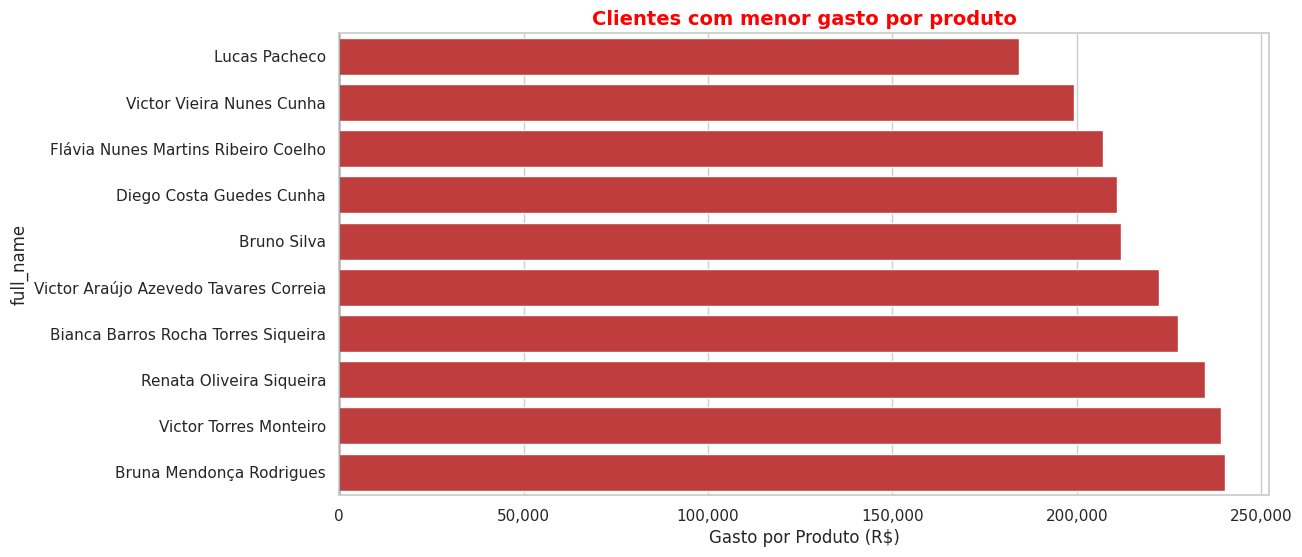

In [ ]:
# Calculando Gasto médio por cliente
analise_gasto = df_final.groupby('full_name').agg({
    'total': 'sum',
    'id': 'count'
})
analise_gasto['ticket_medio'] = analise_gasto['total'] / analise_gasto['id']

piores_tickets = analise_gasto.sort_values(by='ticket_medio', ascending=True).head(10)

print("--- Clientes com Menor Gasto por Produto ---")
display(piores_tickets)

#Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(x=piores_tickets['ticket_medio'], y=piores_tickets.index.get_level_values(0), color='#d62728')
plt.title('Clientes com menor gasto por produto', fontsize=14, fontweight='bold', color='red')
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Gasto por Produto (R$)')
plt.axvline(0, color='black', linewidth=1)
plt.show()

- Clientes que compram produtos que dão prejuizo

--- Detalhamento: Cliente vs. Produto no Prejuízo ---


,,lucro_bruto,qtd
full_name,name,,
Letícia Torres Peixoto Oliveira,Motor Diesel Yanmar Velocity 37HP,"-4,141,993.09",1008
Márcia Figueiredo,Motor de Popa Tohatsu Boost Swift 126HP,"-3,315,920.22",416
Luís Paiva Costa Cardoso Coelho,Motor Diesel Yanmar Velocity 37HP,"-3,132,740.37",552
Thiago Moreira,Motor Diesel Yanmar Velocity 37HP,"-2,965,772.73",672
Pedro Ribeiro Costa Santos Correia,Motor Diesel Honda Aero 205HP,"-2,856,222.01",574
Francisca Ribeiro Pinheiro,Motor Diesel Yanmar Velocity 37HP,"-2,847,201.26",528
Diego Costa Tavares Antunes,Motor Diesel Yanmar Velocity 37HP,"-2,768,836.10",408
Luiz Borges Gomes Araújo,Motor Diesel Yanmar Velocity 37HP,"-2,720,439.93",672
Rafael Pereira Barros,Motor Diesel Yanmar Velocity 37HP,"-2,280,217.96",336


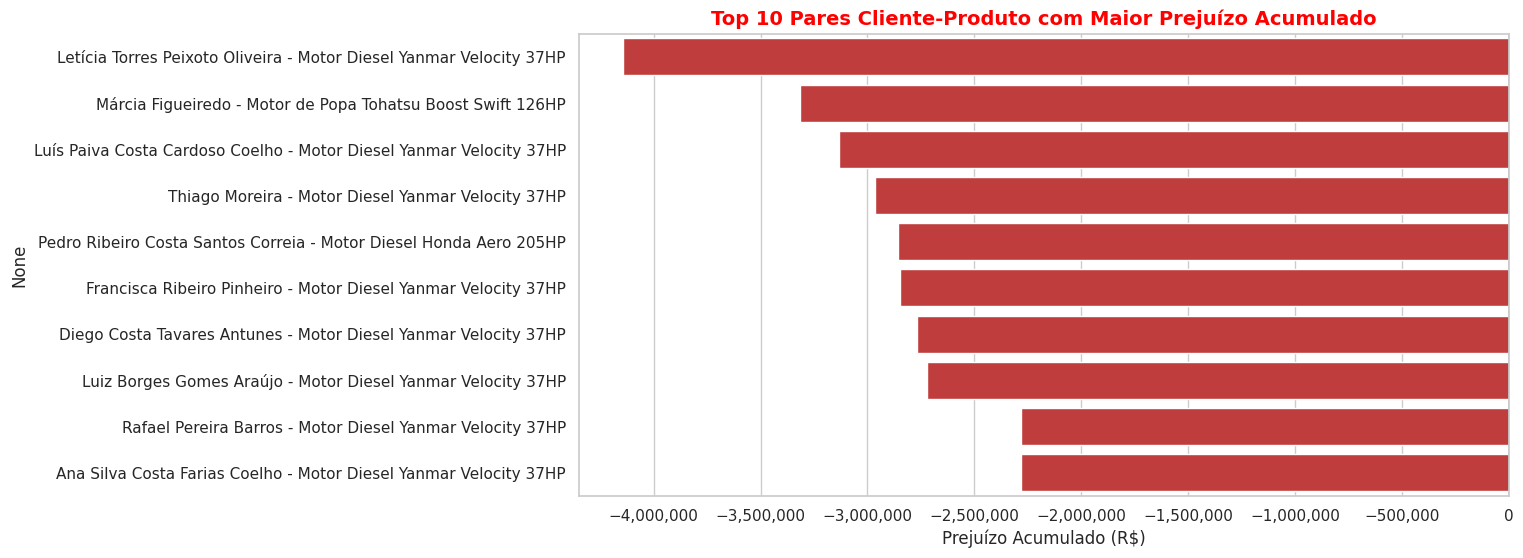

In [ ]:
clientes_produtos_ruins = df_final[df_final['lucro_bruto'] < 0].groupby(['full_name', 'name']).agg({
    'lucro_bruto': 'sum',
    'qtd': 'sum'
}).sort_values(by='lucro_bruto', ascending=True).head(10)

print("--- Detalhamento: Cliente vs. Produto no Prejuízo ---")
display(clientes_produtos_ruins)


plt.figure(figsize=(12, 6))
sns.barplot(x=clientes_produtos_ruins['lucro_bruto'], y=clientes_produtos_ruins.index.map(lambda x: f'{x[0]} - {x[1]}'), color='#d62728')
plt.title('Top 10 Pares Cliente-Produto com Maior Prejuízo Acumulado', fontsize=14, fontweight='bold', color='red')
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel('Prejuízo Acumulado (R$)')
plt.axvline(0, color='black', linewidth=1)
plt.show()

- Curva ABC de Clientes


> Quem são os 20% de Clientes que contribui a 80% do faturamento



,full_name,total
classe,,
A (VIP),31,"15,678,720,792.65"
B (Intermediário),11,"4,606,534,844.15"
C (Baixo Valor),7,"2,433,512,875.85"


--- Tabela Curva ABC (Em Bilhões de R$) ---


,Qtd. Clientes,total
classe,,
A (VIP),31,R$ 15.68B
B (Intermediário),11,R$ 4.61B
C (Baixo Valor),7,R$ 2.43B


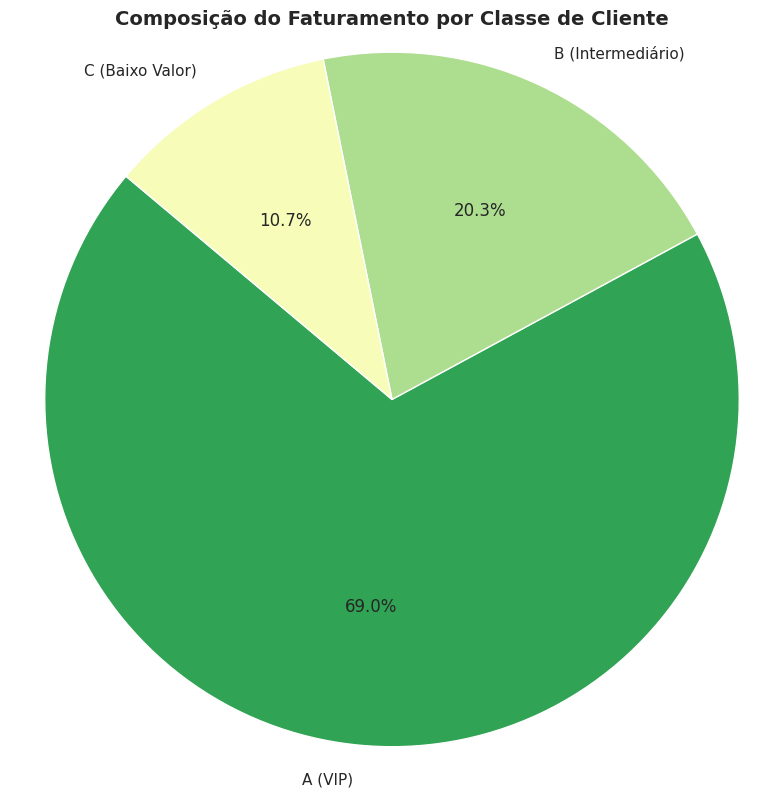

In [ ]:
# Clientes pelo faturamento total
abc_clientes = df_final.groupby('full_name')['total'].sum().sort_values(ascending=False).reset_index()

# Porcentagem acumulada
abc_clientes['percent_acumulado'] = 100 * abc_clientes['total'].cumsum() / abc_clientes['total'].sum()

# Classes (A: até 70%, B: 70-90%, C: 90-100%)
def classificar_abc(p):
    if p <= 70: return 'A (VIP)'
    elif p <= 90: return 'B (Intermediário)'
    else: return 'C (Baixo Valor)'

abc_clientes['classe'] = abc_clientes['percent_acumulado'].apply(classificar_abc)

# Resumo
resumo_abc = abc_clientes.groupby('classe').agg({'full_name': 'count', 'total': 'sum'})
display(resumo_abc)

tabela_abc_formatada = resumo_abc.copy()

#  'total' para Reais Bilhões (com 2 casas decimais)
tabela_abc_formatada['total'] = tabela_abc_formatada['total'].apply(lambda x: f'R$ {x/1e9:.2f}B')
tabela_abc_formatada = tabela_abc_formatada.rename(columns={'full_name': 'Qtd. Clientes'})

print("--- Tabela Curva ABC (Em Bilhões de R$) ---")
display(tabela_abc_formatada)

# 3. Gráfico de Pizza
plt.figure(figsize=(8, 8))
# Dados brutos (não formatados) para o gráfico
plt.pie(resumo_abc['total'], labels=resumo_abc.index, autopct='%1.1f%%', startangle=140, colors=['#31a354', '#addd8e', '#f7fcb9'])
plt.title('Composição do Faturamento por Classe de Cliente', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

- Recorrencia de Clientes

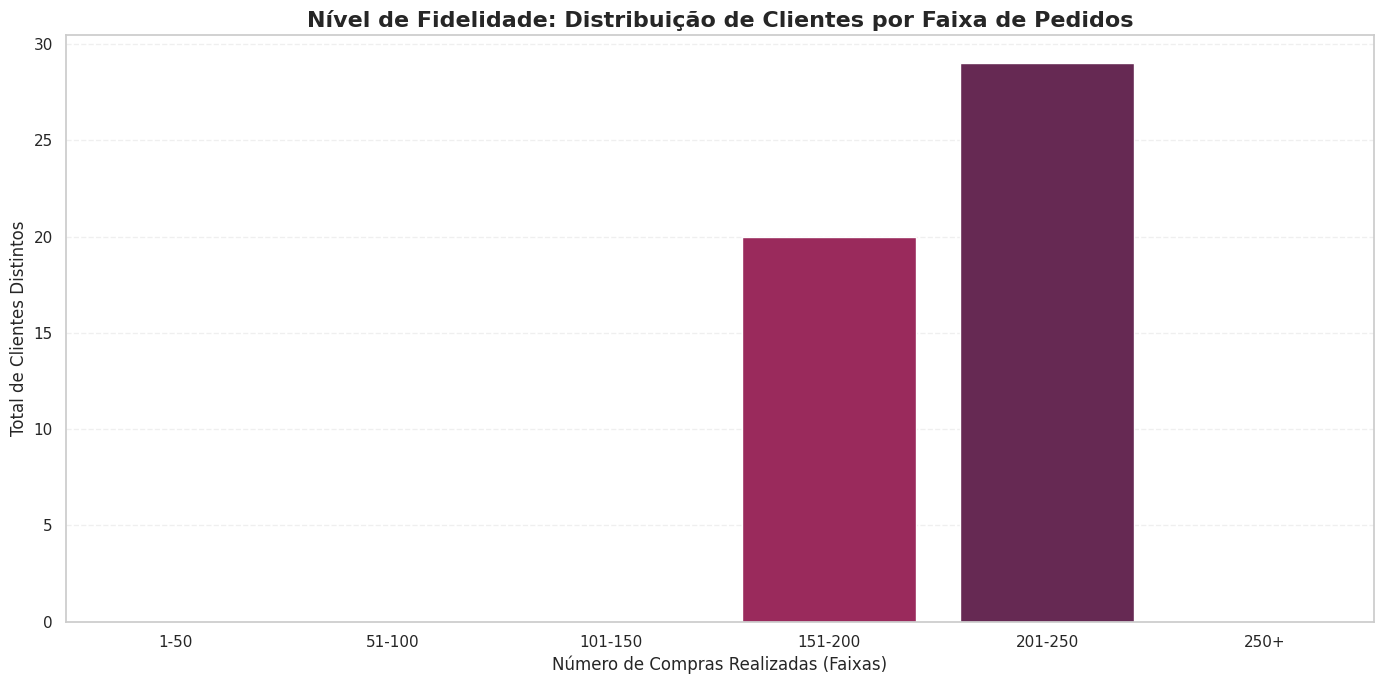

In [ ]:
# Quantos pedidos cada cliente fez
pedidos_por_cliente_raw = df_final.groupby('full_name')['id'].nunique()

# Definimos as faixas (Bins) e as etiquetas
bins = [0,  50,  100, 150, 200, 250, np.inf]
labels = ['1-50',  '51-100',  '101-150', '151-200', '201-250', '250+']

# Series com os dados classificados nas faixas
fidelidade_binned = pd.cut(pedidos_por_cliente_raw, bins=bins, labels=labels).value_counts().sort_index()

# Gráfico Simplificado
plt.figure(figsize=(14, 7))
sns.barplot(x=fidelidade_binned.index, y=fidelidade_binned.values, palette="rocket_r")


plt.title('Nível de Fidelidade: Distribuição de Clientes por Faixa de Pedidos', fontsize=16, fontweight='bold')
plt.ylabel('Total de Clientes Distintos', fontsize=12)
plt.xlabel('Número de Compras Realizadas (Faixas)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#Previsão de Demandas

- Dataframe de series temporais

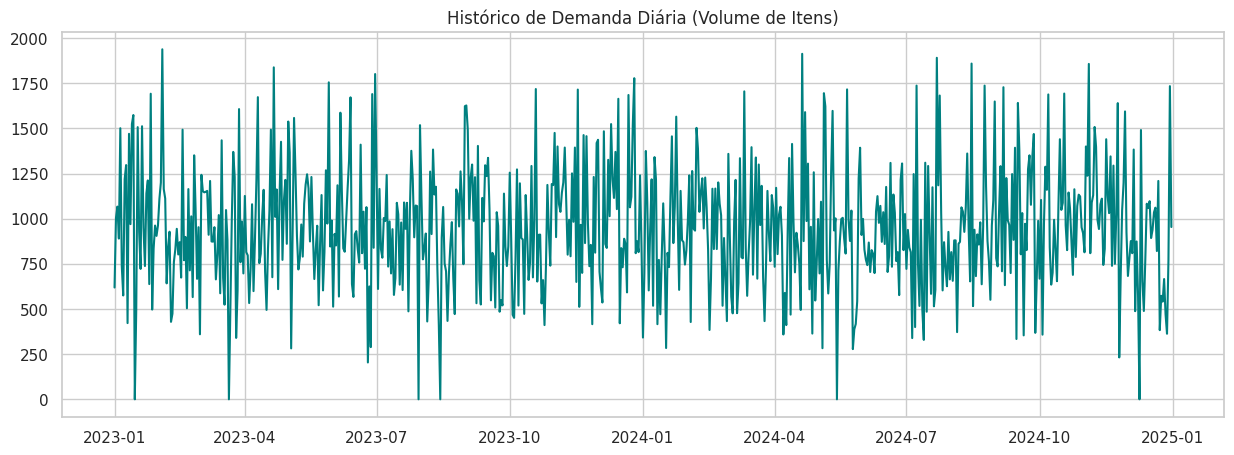

In [ ]:
# Agrupado por dia para ver a volatilidade real
demanda_diaria = df_final.resample('D', on='sale_date')['qtd'].sum().reset_index()

# Gráfico de conferência (Baseline)
plt.figure(figsize=(15, 5))
plt.plot(demanda_diaria['sale_date'], demanda_diaria['qtd'], color='teal')
plt.title('Histórico de Demanda Diária (Volume de Itens)')
plt.show()

- Média movel

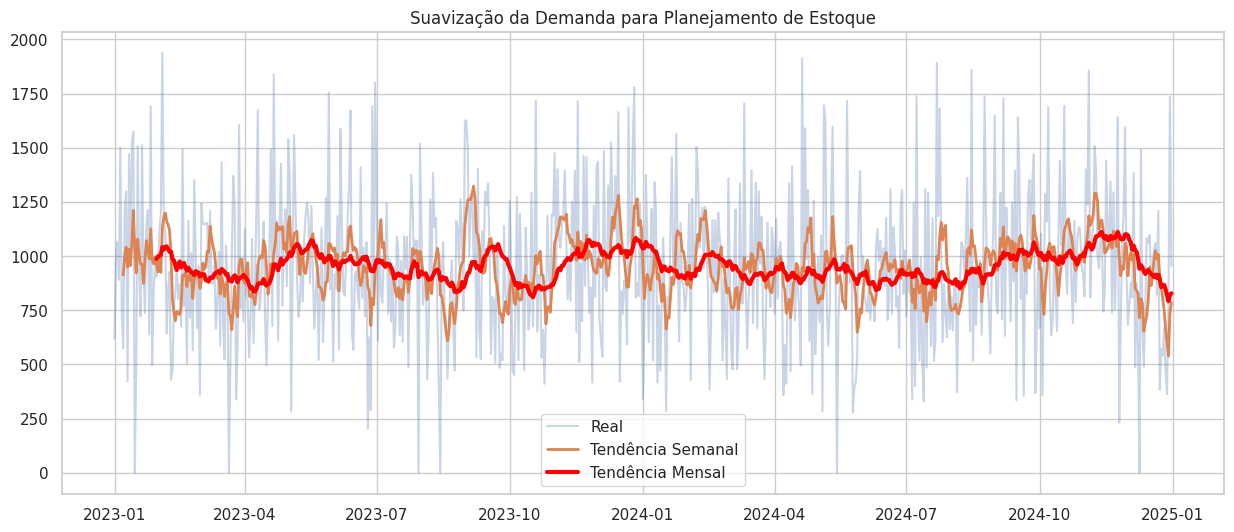

In [ ]:
# Calculando a média móvel de 7 dias (semanal) e 30 dias (mensal)
demanda_diaria['media_7d'] = demanda_diaria['qtd'].rolling(window=7).mean()
demanda_diaria['media_30d'] = demanda_diaria['qtd'].rolling(window=30).mean()

plt.figure(figsize=(15, 6))
plt.plot(demanda_diaria['sale_date'], demanda_diaria['qtd'], alpha=0.3, label='Real')
plt.plot(demanda_diaria['sale_date'], demanda_diaria['media_7d'], label='Tendência Semanal', linewidth=2)
plt.plot(demanda_diaria['sale_date'], demanda_diaria['media_30d'], label='Tendência Mensal', linewidth=3, color='red')
plt.legend()
plt.title('Suavização da Demanda para Planejamento de Estoque')
plt.show()

- Preparando dados

In [ ]:
# Agrupando a demanda por dia
df_prophet = df_final.groupby(df_final['sale_date'].dt.date)['qtd'].sum().reset_index()
df_prophet.columns = ['data', 'qtd']

# 2. Variável 'dias_sequenciais' (feature X)
df_prophet['dias_desde_inicio'] = (pd.to_datetime(df_prophet['data']) - pd.to_datetime(df_prophet['data'].min())).dt.days

#  X (independente) e y (dependente)
X = df_prophet[['dias_desde_inicio']]
y = df_prophet['qtd']

- Treinando o modelo de Regressão Linear

In [ ]:
# Criando e treinando o modelo
modelo = LinearRegression()
modelo.fit(X, y)
#Previsões para o passado (para comparar com o real)
df_prophet['previsao_modelo'] = modelo.predict(X)

print(f"Coeficiente de inclinação: {modelo.coef_[0]:.2f}")

Coeficiente de inclinação: -0.01


In [ ]:
for cat in df_final['actual_category'].unique():
    df_cat = df_final[df_final['actual_category'] == cat].groupby(df_final['sale_date'].dt.date)['qtd'].sum().reset_index()
    df_cat['dias'] = (pd.to_datetime(df_cat['sale_date']) - pd.to_datetime(df_cat['sale_date'].min())).dt.days

    if len(df_cat) > 1:
        m = LinearRegression().fit(df_cat[['dias']], df_cat['qtd'])
        print(f"Categoria {cat}: Inclinação {m.coef_[0]:.4f}")

Categoria ANCORAGEM: Inclinação -0.0561
Categoria ELETRONICOS: Inclinação 0.0108
Categoria PROPULSAO: Inclinação 0.0398


#Sistemas de recomendações

In [ ]:
# matriz: Linha = Cliente, Coluna = Produto
matriz_vendas = df_final.pivot_table(index='id_client', columns='name', values='qtd', aggfunc='sum').fillna(0)


# Matriz Binaria
matriz_binaria = matriz_vendas.applymap(lambda x: 1 if x > 0 else 0)

print(f"Matriz pronta: {matriz_binaria.shape[0]} clientes e {matriz_binaria.shape[1]} produtos.")

# Calculamos a similaridade entre as colunas (produtos)
item_similarity = cosine_similarity(matriz_binaria.T)

# Transformamos em um DataFrame para facilitar a busca por nome
df_sim = pd.DataFrame(item_similarity, index=matriz_binaria.columns, columns=matriz_binaria.columns)

Matriz pronta: 49 clientes e 150 produtos.


- Função de Recomendação

In [ ]:
def recomendar_proximo_passo(produto_comprado, n_recomendações=3):
    if produto_comprado not in df_sim.columns:
        return "Produto não mapeado."

    # Busca os itens mais similares, ignorando o próprio item
    similares = df_sim[produto_comprado].sort_values(ascending=False).iloc[1:n_recomendações+1]

    return similares


- Teste com item

In [ ]:
# Recomendação para quem compra um 'Motor de Popa'
test_item = "Motor de Popa Honda Vector Kinetic 174HP" # Ajuste para um nome real do seu DF
print(f"Quem comprou '{test_item}', também costuma ter interesse em:")
print(recomendar_proximo_passo(test_item))

Quem comprou 'Motor de Popa Honda Vector Kinetic 174HP', também costuma ter interesse em:
name
Cabo de Nylon Delta Velocity Oceanic Abyss     0.85
Motor Diesel Tohatsu Evo Zenith 16HP           0.84
Motor de Popa Torqeedo Core Hydra Flux 162HP   0.82
Name: Motor de Popa Honda Vector Kinetic 174HP, dtype: float64
